##Import Library

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Pembersihan Data

##Load Data

In [41]:
df=pd.read_csv('covid_19_indonesia.csv')
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Jumlah baris  : 31822
Jumlah kolom  : 38


,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,75,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,192.31%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,75,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,182.93%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,1,0,1,...,0.511648,0.16,0.16,0.0,0.00,0.00,0.00%,100.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,75,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,174.42%,1.0,1.0


##Cek Missing Values

In [42]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
print(missing_df[missing_df['Jumlah Missing'] > 0])

                             Jumlah Missing  Persentase (%)
City or Regency                       31822          100.00
Province                                929            2.92
Island                                  929            2.92
Time Zone                               929            2.92
Special Status                        27264           85.68
Total Cities                            901            2.83
Total Urban Villages                    904            2.84
Total Rural Villages                    929            2.92
Growth Factor of New Cases             1939            6.09
Growth Factor of New Deaths            3447           10.83


##Cek Duplikat

In [43]:
print(f'Jumlah duplikat: {df.duplicated().sum()}')

Jumlah duplikat: 0


##Salin DataFrame

In [44]:
df_clean = df.copy()
print('Dataframe disalin ✅')

Dataframe disalin ✅


##Konversi Kolom Date

In [45]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
print(df_clean['Date'].dtype)

datetime64[ns]


##Konversi Kolom Persentase

In [46]:
df_clean['Case Fatality Rate'] = (
    df_clean['Case Fatality Rate']
    .str.replace('%', '', regex=False)
    .astype(float)
)

df_clean['Case Recovered Rate'] = (
    df_clean['Case Recovered Rate']
    .str.replace('%', '', regex=False)
    .astype(float)
)
print('Kolom persentase dikonversi ✅')

Kolom persentase dikonversi ✅


In [47]:
##Tangani Missing Values

In [48]:
df_clean['City or Regency']      = df_clean['City or Regency'].fillna('N/A')
df_clean['Province']             = df_clean['Province'].fillna('N/A')
df_clean['Island']               = df_clean['Island'].fillna('N/A')
df_clean['Time Zone']            = df_clean['Time Zone'].fillna('N/A')
df_clean['Special Status']       = df_clean['Special Status'].fillna('None')
df_clean['Total Cities']         = df_clean['Total Cities'].fillna(0).astype(int)
df_clean['Total Urban Villages'] = df_clean['Total Urban Villages'].fillna(0).astype(int)
df_clean['Total Rural Villages'] = df_clean['Total Rural Villages'].fillna(0).astype(int)
df_clean['Growth Factor of New Cases']  = df_clean['Growth Factor of New Cases'].fillna(0)
df_clean['Growth Factor of New Deaths'] = df_clean['Growth Factor of New Deaths'].fillna(0)

print('Missing values ditangani ✅')

Missing values ditangani ✅


##Hapus Duplikat

In [49]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Duplikat dihapus: {before - after} baris')

Duplikat dihapus: 0 baris


##Rename Kolom

In [50]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)
print('Kolom berhasil direname ✅')

Kolom berhasil direname ✅


##Validasi & Simpan

In [51]:
print(f'Total missing tersisa: {df_clean.isnull().sum().sum()}')
print(f'Shape akhir: {df_clean.shape}')

df_clean.to_csv('covid_indonesia_clean.csv', index=False)
print('Tersimpan sebagai covid_indonesia_clean.csv ✅')

Total missing tersisa: 0
Shape akhir: (31822, 38)
Tersimpan sebagai covid_indonesia_clean.csv ✅


#EDA (Exploratory Data Analysis)

##Statistik Dasar

In [52]:
df_clean[['new_cases', 'new_deaths', 'new_recovered']].describe()

,new_cases,new_deaths,new_recovered
count,31822.000000,31822.000000,31822.000000
mean,402.311388,9.920652,390.398498
std,2320.629838,64.139080,2199.878802
min,0.000000,0.000000,0.000000
25%,3.000000,0.000000,2.000000
50%,27.000000,0.000000,20.000000
75%,130.000000,3.000000,123.000000
max,64718.000000,2069.000000,61361.000000


##Tren Kasus Harian

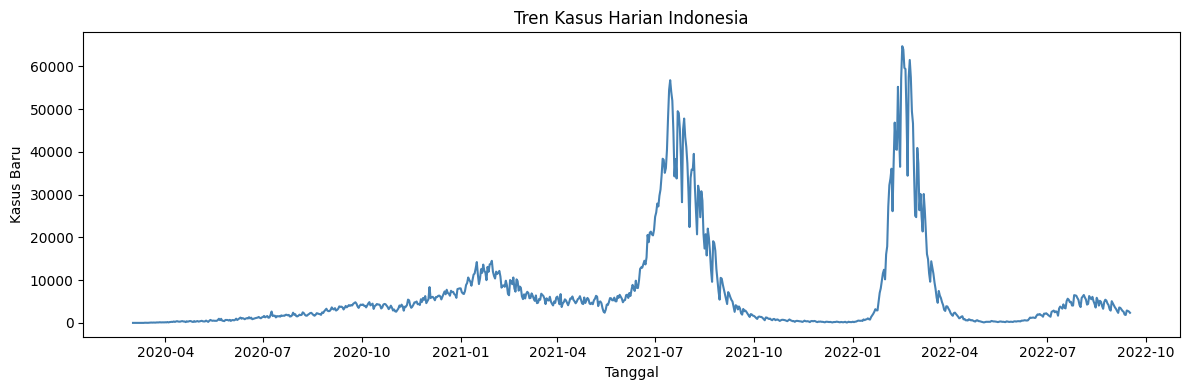

In [53]:
nasional = df_clean[df_clean['location'] == 'Indonesia']

plt.figure(figsize=(12, 4))
plt.plot(nasional['date'], nasional['new_cases'], color='steelblue')
plt.title('Tren Kasus Harian Indonesia')
plt.xlabel('Tanggal')
plt.ylabel('Kasus Baru')
plt.tight_layout()
plt.show()

##5 Provinsi Kasus Tertinggi

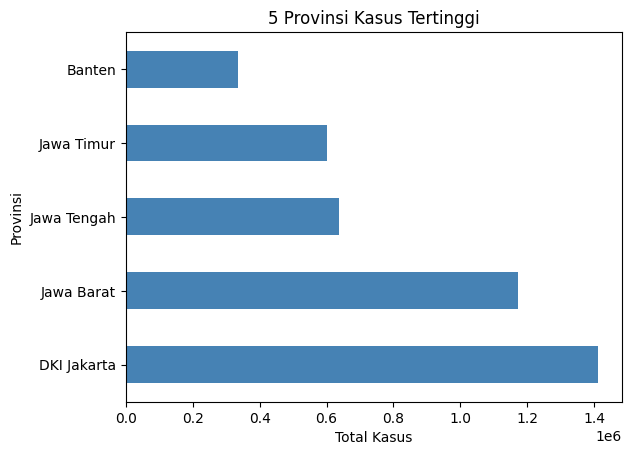

In [54]:
provinsi = df_clean[df_clean['location_level'] == 'Province']
latest = provinsi.sort_values('date').groupby('location').last().reset_index()

top5 = latest.nlargest(5, 'total_cases')[['location', 'total_cases']]

top5.plot(kind='barh', x='location', y='total_cases', color='steelblue', legend=False)
plt.title('5 Provinsi Kasus Tertinggi')
plt.xlabel('Total Kasus')
plt.ylabel('Provinsi')
plt.show()

##Ringkasan Angka

In [55]:
print('====== RINGKASAN ======')
print(f"Total kasus   : {nasional['total_cases'].max():,}")
print(f"Total kematian: {nasional['total_deaths'].max():,}")
print(f"Total sembuh  : {nasional['total_recovered'].max():,}")
print(f"Puncak kasus  : {nasional['new_cases'].max():,}")
print(f"Puncak terjadi: {nasional.loc[nasional['new_cases'].idxmax(), 'date'].date()}")

====== RINGKASAN ======
Total kasus   : 6,405,044
Total kematian: 157,876
Total sembuh  : 6,218,708
Puncak kasus  : 64,718
Puncak terjadi: 2022-02-16
